In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps
import pymiediff as pmd
import time
# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

homogeneous particle (on device: cpu)
 - layers   = 1
 - radii    = tensor([400.])nm
 - materials: ['eps=1.56+i3.200']
 - environment    : eps=1.00

tensor([274.5058, 273.7871, 271.6404, 268.0966, 263.2036, 257.0287, 249.6560,
        241.1846, 231.7265, 221.4044, 210.3505, 198.7021, 186.6005, 174.1874,
        161.6032, 148.9846, 136.4612, 124.1548, 112.1774, 100.6294,  89.5983,
         79.1584,  69.3701,  60.2794,  51.9181,  44.3049,  37.4451,  31.3323,
         25.9488,  21.2676,  17.2529,  13.8626,  11.0488,   8.7599,   6.9419,
          5.5395,   4.4976,   3.7625,   3.2825,   3.0094,   2.8983,   2.9088,
          3.0051,   3.1561,   3.3355,   3.5217,   3.6978,   3.8510,   3.9723,
          4.0563,   4.1005,   4.1048,   4.0712,   4.0032,   3.9055,   3.7834,
          3.6426,   3.4886,   3.3269,   3.1624,   2.9995,   2.8418,   2.6923,
          2.5529,   2.4253,   2.3099,   2.2070,   2.1160,   2.0363,   1.9665,
          1.9055,   1.8517,   1.8037,   1.7601,   1.7197,   1.6815,   1

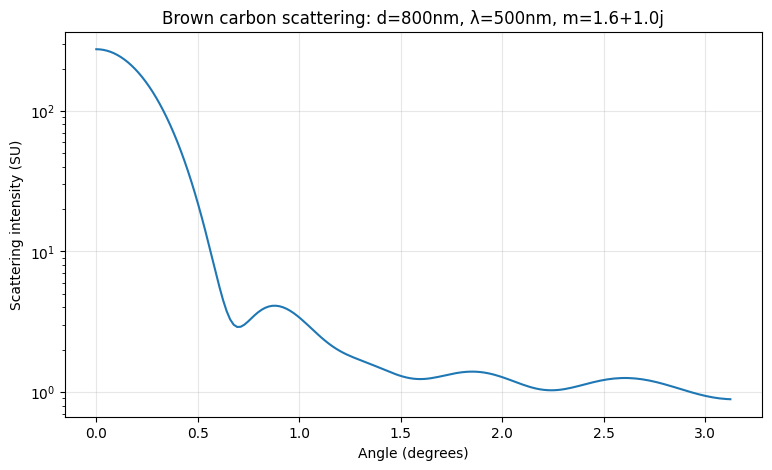

In [5]:

def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    print(p)
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    print(angle_scattering["i_unpol"])
    
    return angle_scattering['i_unpol']

# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm
theta = torch.arange(0, 181) * torch.pi/181

scattering = py_Mie_Diff_Scattering(wavelength, diameter, n, k)

plt.figure(figsize=(9, 5))
plt.plot(theta, scattering)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()